<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [341]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt


In [729]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 

In [342]:
connection = psycopg2.connect(
    dbname='project_sql',
    user='skillfactory',
    host='84.201.134.129',
    password='cCkxxLVrDE8EbvjueeMedPKt',
    port=5432
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [731]:
# текст запроса
query_3_1 = f'''select count(id) vacancies_total 
            from vacancies
         '''

In [732]:
# результат запроса
df_3_1 = pd.read_sql_query(query_3_1, connection)
df_3_1

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\4045908245.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_1 = pd.read_sql_query(query_3_1, connection)


,vacancies_total
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [36]:
# текст запроса
query_3_2 = f'''select count(id) employers_total  
            from employers
         '''

In [37]:
# результат запроса
df_3_2 = pd.read_sql_query(query_3_2, connection)
df_3_2

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\533540996.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_2 = pd.read_sql_query(query_3_2, connection)


,employers_total
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [353]:
# текст запроса
query_3_3 = f'''select count(id) areas_total
            from areas
         '''

In [354]:
# результат запроса
df_3_3 = pd.read_sql_query(query_3_3, connection)
df_3_3

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\1395976625.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_3 = pd.read_sql_query(query_3_3, connection)


,areas_total
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [359]:
# текст запроса
query_3_4 = f'''select count(id) industries_total 
            from industries
         '''

In [360]:
# результат запроса
df_3_4 = pd.read_sql_query(query_3_4, connection)
df_3_4

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\854197215.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_4 = pd.read_sql_query(query_3_4, connection)


,industries_total
0,294


***

In [122]:
# выводы по предварительному анализу данных

### <span style="color:lightgreen">Предварительный анализ: выводы</span>

Судя по составу полей, данные таблицы \ справочники могут представлять собой "выдержку" из таблиц \ справочников, содержащих гораздо бОльше информации, и как следствие, накладывать некоторые ограничения для варианты анализа. Например:
- Таблица *vacancies* не содержит дату размещения вакансии, ее статус, дату изменения статуса, количество откликов \ просмотров и пр. Как минимум это не позволит проанализировать динамику размещения \ закрытия вакансий во времени, скорость закрытия вакансий и пр. Названия вакансий указаны произвольно, т.е. не соотносятся с каким-то справочником вакансий, следовательно анализ предложений по направлению деятельности затруднен.
- Справочник *employers* содержит только уникальный id самого источника и не содержит общепринятые уникальные коды, например, ИНН, позволяющие однозначно идентифицировать компанию, отслеживать изменения в юридическом наименовании, адресе регистрации и пр. Также нет указания головной компании, чтобы проанализировать, например, все объявления компаний, входящих в группу компаний.
- Справочник *areas* должен содержать, судя по комментариям, информацию о городах. Однако в нем вперемешку с городами приведены страны. В этом случе сложнее делать региональный анализ, допустим, выделить вакансии \ работодеталей в РФ и за рубежом, да и статистика по городам может быть искажена.
- Таблица-справочник *industries* не содержит более высокий уровень группировки, хотя она фактически отражается в структуре кода (общая цифра перед разделителем как признак общей группы). Наличие полноценного классификатора (типа ОКВЭД) позволил бы сделать анализ по работодателям с разным уровнем детализации, в том числе и более укрупненнный. Например, выделить вакансии работотодателей со сферой деятельности "Связь", куда входит связь мобильная, фиксированная, спутниковая и пр.

<span style="color:lightgreen">Количество записей в таблицах и таблицах-справочниках:</span>

| Таблица  | Всего |
| ------------- | ------------- |
| Вакансии  | 49197  |
| Работодатели  | 23501  |
| Регионы  | 1362  |
| Сферы деятельности  | 294  |



# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [302]:
# текст запроса
query_4_1 = f'''select a.name area, count(v.id) cnt
            from areas a
            join vacancies v on a.id = v.area_id
            group by a.name
            order by cnt desc
         '''

In [307]:
# результат запроса
df_4_1 = pd.read_sql_query(query_4_1, connection)
display(df_4_1[:10])

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\749622400.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_1 = pd.read_sql_query(query_4_1, connection)


,area,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
5,Екатеринбург,1698
6,Нижний Новгород,1670
7,Казань,1415
8,Краснодар,1301
9,Самара,1144


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [72]:
# текст запроса
query_4_2 = f'''select count(id) salary_available
                from vacancies
                where salary_from is not NULL or salary_to is not NULL
            '''

In [73]:
# результат запроса
df_4_2 = pd.read_sql_query(query_4_2, connection)
df_4_2

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_10888\3746829199.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_2 = pd.read_sql_query(query_4_2, connection)


,salary_available
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [102]:
# текст запроса
query_4_3 = f'''select  
                    round(avg(salary_from)) lower_limit, 
                    round(avg(salary_to)) upper_limit
                from vacancies
                where salary_from is not NULL or salary_to is not NULL
            '''

In [103]:
# результат запроса
df_4_3 = pd.read_sql_query(query_4_3, connection)
df_4_3

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_10888\3595259731.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_3 = pd.read_sql_query(query_4_3, connection)


,lower_limit,upper_limit
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [104]:
# текст запроса
query_4_4 = f'''select 
                    schedule,
                    employment,
                    count(id) vacancies
                from vacancies
                group by schedule, employment
                order by vacancies desc
            '''

In [106]:
# результат запроса
df_4_4 = pd.read_sql_query(query_4_4, connection)
df_4_4

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_10888\2028972612.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_4 = pd.read_sql_query(query_4_4, connection)


,schedule,employment,vacancies
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [117]:
# текст запроса
query_4_5 = f'''select experience, count(id) vacancies
                from vacancies
                group by experience
                order by vacancies asc
            '''

In [118]:
# результат запроса
df_4_5 = pd.read_sql_query(query_4_5, connection)
df_4_5

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_10888\210463167.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_5 = pd.read_sql_query(query_4_5, connection)


,experience,vacancies
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

In [ ]:
# выводы по детальному анализу вакансий

### <span style="color:lightgreen">Анализ вакансий: выводы</span>

1. Почти треть вакансий приходится на топ-5 регионов, и это столицы и\или города-миллионники: Москва, Санкт-Петербург, Минск, Новосибирск, Алматы. Причем Москва идет с отрывом почти в два раза по сравнению с остальными лидерами.
2. Зарплата указана примерно для половины вакансий. Есть вопросы к данным там, где з\п все-таки указана: когда, например, указан минимальный уровень в 105 рублей при максимальном в 215000. Но если анализировать "среднюю по больнице", то минимальная зарплата составляет ≈71 тыс. рублей, максимальная - почти в 1.5 раза больше, (≈111 тысяч).
4. Основной тип трудоустройка (94% выборки) - полная занятость. Что касается графика, в первую очередь работодателю требуются сотрудники на полный рабочий день (почти 2/3 объявлений), лишь 4% предполагают гибкий график. Вызывает вопрос, что значит "удаленная" работа в контексте графика. Обычно это означает работу вне офиса, а не собственнно распределение времени, отведенное на выполнение работы. Тем не менее именно с такой формулировкой опубликовано 19% вакансий. 
5. Традиционно бóльшая часть позиций предполагает наличие опыта. Однако лишь 30% вакансий рассчитано на специалистов с отпытом от 3 лет, и чуть более 2% - на высокоопытных (от 6 лет). В целом планка по минимальному опыту - от 1 года (почти половина выборки), плюс ≈15% объявлений для "нулевых" соискателей (т.е. не требуют опыта вообще, хотя большинство из них и рассчитаны на полную занятость). Стажировки при этом не пользуются популярностью - на них приходится от силы 1.5% вакансий (и даже чуть меньше, если исключить вакансии с требованием к стажеру по опыту).

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [698]:
# текст запроса
query_5_1 = f'''(select
                    '1' rating,
                    e.name,
                    count(v.id) vacancies
                from employers e
                join vacancies v on e.id = v.employer_id
                group by e.name
                order by vacancies desc
                limit 1)
                union
                (select
                    '5' rating,
                    e.name,
                    count(v.id) vacancies
                from employers e
                join vacancies v on e.id = v.employer_id
                group by e.name
                order by vacancies desc
                offset 4
                limit 1)
            '''

In [699]:
# результат запроса
df_5_1 = pd.read_sql_query(query_5_1, connection)
df_5_1

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\1147638897.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_1 = pd.read_sql_query(query_5_1, connection)


,rating,name,vacancies
0,1,Яндекс,1933
1,5,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [290]:
# текст запроса
# для каждого региона определяется количество зарегистрированных в нем работодателей и количество их вакансий по месту регистрации
query_5_2 = f'''(select 
                    a.name reg_region,
                    count(distinct e.id) employers,
                    count(v.id) vacancies_by_reg_region
                from areas a
                left join employers e on a.id = e.area
                left join vacancies v on v.area_id = a.id and v.employer_id = e.id
                group by reg_region
                having count(v.id) > 0
                order by vacancies_by_reg_region desc, employers desc)
                union all
                (select 
                    a.name reg_region,
                    count(distinct e.id) employers,
                    count(v.id) vacancies_by_reg_region
                from areas a
                left join employers e on a.id = e.area
                left join vacancies v on v.area_id = a.id and v.employer_id = e.id
                group by reg_region  
                having count(v.id) = 0
                order by employers desc
                limit 1)
            '''

In [291]:
# результат запроса
df_5_2 = pd.read_sql_query(query_5_2, connection)
df_5_2

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\2306256317.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_2 = pd.read_sql_query(query_5_2, connection)


,reg_region,employers,vacancies_by_reg_region
0,Москва,5864,4567
1,Минск,1115,1858
2,Санкт-Петербург,2217,1811
3,Алматы,721,1069
4,Екатеринбург,609,960
...,...,...,...
350,Осинники,1,1
351,Власиха,1,1
352,Орша,1,1
353,Троицк (Московская область),1,1


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [90]:
# текст запроса
query_5_3 = f'''select  
                    e.name employer,
                    count(distinct v.area_id) regions
                from vacancies v
                join employers e on v.employer_id = e.id
                group by e.id, e.name
                order by count(v.id) desc
                '''

In [91]:
# результат запроса
df_5_3 = pd.read_sql_query(query_5_3, connection)
df_5_3

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\133400711.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_3 = pd.read_sql_query(query_5_3, connection)


,employer,regions
0,Яндекс,181
1,Ростелеком,152
2,Тинькофф,43
3,СБЕР,24
4,Газпром нефть,24
...,...,...
14901,Торговый Дом Петровский,1
14902,А2 Юнайтед,1
14903,ТСЦ Дровосек,1
14904,ПАВЛОДАРЭНЕРГО,1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [64]:
# текст запроса
query_5_4 = f'''select
                    count(e.id) employers_without_industry
                from employers e
                left join employers_industries ei on ei.employer_id = e.id
                where ei.industry_id is NULL                
            '''

In [65]:
# результат запроса
df_5_4 = pd.read_sql_query(query_5_4,connection)
df_5_4

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\2275062446.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_4 = pd.read_sql_query(query_5_4,connection)


,employers_without_industry
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [206]:
# текст запроса
query_5_5 = f'''select e.name employer
                from employers_industries ei
                join employers e on ei.employer_id = e.id
                group by e.name
                having count(ei.industry_id) = 4
                order by e.name asc
                offset 2
                limit 1
                '''

In [207]:
# результат запроса
df_5_5 = pd.read_sql_query(query_5_5, connection)
df_5_5

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\4025176131.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_5 = pd.read_sql_query(query_5_5, connection)


,employer
0,2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [229]:
# текст запроса
query_5_6 = f'''select count(ie.industry_id) employers_no
                from employers_industries ie
                join industries i on ie.industry_id = i.id
                where i.name = 'Разработка программного обеспечения'
            '''

In [230]:
# результат запроса
df_5_6 = pd.read_sql_query(query_5_6, connection)
df_5_6

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\2713946032.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_6 = pd.read_sql_query(query_5_6, connection)


,employers_no
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [294]:
# код для получения списка городов-милионников
import requests
from bs4 import BeautifulSoup
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
response_wiki = requests.get(url)
page_wiki = BeautifulSoup(response_wiki.text, 'html.parser')
list_wiki = list() # пустой список для добавления в него всех названий городов
columns = page_wiki.find_all('td') # ищем все столбцы по тегу <td>
# названия городов - это гипертекстовые ссылки, находим их все
for column in columns:
    links = column.find_all('a')
    for link in links:  # добавляем текст ссылок в лист
        list_wiki.append(link.text)
# выводим список первых 16 городов в соответствии со статьей Wiki
# список удобно копировать для вставки в SQL WHERE IN для фильтрации городов
print(list_wiki[:16])

['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Самара', 'Ростов-на-Дону', 'Краснодар', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']


In [285]:
# текст запроса
query_5_7 = f'''select 
                    a.name region, 
                    count(v.id) vacancies
                from vacancies v
                join areas a on a.id = v.area_id
                join employers e on e.id = v.employer_id
                where e.name = 'Яндекс' and a.name in ('Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Самара', 'Ростов-на-Дону', 'Краснодар', 'Омск', 'Воронеж', 'Пермь', 'Волгоград')
                group by region
                union all
                select
                    'TOTAL',
                    count(v.id)                
                    from vacancies v
                join areas a on a.id = v.area_id
                join employers e on e.id = v.employer_id
                where e.name = 'Яндекс' and a.name in ('Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Самара', 'Ростов-на-Дону', 'Краснодар', 'Омск', 'Воронеж', 'Пермь', 'Волгоград')
                order by vacancies
                '''

In [286]:
# результат запроса
df_5_7 = pd.read_sql_query(query_5_7, connection)
df_5_7

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\2595257991.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_7 = pd.read_sql_query(query_5_7, connection)


,region,vacancies
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Казань,25
6,Ростов-на-Дону,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

In [ ]:
# выводы по анализу работодателей


### <span style="color:lightgreen">Анализ работодателей: выводы</span>

1. Яндекс - не просто лидер по количеству вакансий среди компаний-работодателей, но экстремум по выборке: количество вакансий в 4 раза больше, чем у серебряного призера Ростелекома. Вообще на первую пятерку приходится 7% всех вакансий.
2. Топ-5 регионов по количеству работодателей похож на топ-5 по вакансиям (см шаг 4.1), разве что вместо Новосибирска в списке Екатеринбург. Если посмотреть на количество вакансий в разбивке по регионам регистрации и сравнить с количество на шаге 4.1., видно, что у Москвы и Санкт-Петербурга (лидеров по количеству вакансий всего) работодателей больше, чем вакансий, в других городах - наоборот. Можно предположить, что компании, зарегистрированные в Москве и СПб, размещают больше вакансий за пределами своего региона. Среди регионов, в которых нет вакансий, наибольшее количество работодателей в России (т.е. конкретный город не проставлен) - в выводах к [Предварительному анализу](#предварительный-анализ-выводы) эта тема уже поднималась.
3. По количеству регионов, в которых публикуются вакансии, Яндекс и Ростелеком опять на лидирующих позициях. Количество регионов у них в разы больше, чем у представителей финансовой сферы Тинькофф и СБЕРа (3 и 4 место), замыкает пятерку Газпром нефть. Такой рейтинг объясним развитой филиальной сетью этих компаний и разнообразными направлениями бизнеса (сфер деятельности), в том числе в IT - см комментарий к п.6.
4. Здесь и при дальнейшем анализе в разбивке по сферам деятельности надо учитывать, что у 36% работодателей сфера деятельности не указана.
5. Большая часть работодателей указывает одну сферу деятельности (43%), примерно столько же приходится на тех, кто указывает 2-3 сферы (41%), порядка 16% указали 4-5 сфер.
6. Больше всего компаний-работодателей указали, что работают в сфере IT: разработка ПО, системная интеграция \ автоматизация, интернет-компании. Возможно, общее название для этих сфер могло быть другим, но они точно относятся к одной группе, судя по общей цифре 7 в их id. 
7. Яндекс ищет сотрудников во всех городах-миллионниках, причем на них приходится четверть всех вакансий компании. За исключением Москвы (11%), СПб (29%), Екатеринбурга (54%), Новосибирска (60%), в среднем на "удаленку" приходится 80-90% объявлений, при этом бóльшая их часть не предполагает наличие опыта, что может быть связано с тем, что рабочая сила в этих городах дешевле и прекрасно подходит на junior позиции.






# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [428]:
# текст запроса
query_6_1 = f'''select count(id) vacancies
                from vacancies
                where lower(name) like '%data%' or lower(name) like '%данн%'
            '''

In [429]:
# результат запроса
df_6_1 = pd.read_sql_query(query_6_1, connection)
df_6_1   

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\2193881639.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_1 = pd.read_sql_query(query_6_1, connection)


,vacancies
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [584]:
# текст запроса
query_6_2 = f'''select count(*) from vacancies
                where 
                    (lower(name) like '%data scientist%' 
                    or lower(name) like '%data science%'
                    or lower(name) like '%исследователь данных%'
                    or (lower(name) like '%ml%' and lower(name) not like '%html%')
                    or lower(name) like '%machine learning%'
                    or lower(name) like '%машинн%обучен%')
                    and
                    (lower(name) like '%junior%'
                    or experience = 'Нет опыта'
                    or employment = 'Стажировка')
                '''

In [585]:
# результат запроса
df_6_2 = pd.read_sql_query(query_6_2, connection)
df_6_2 

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\3875729611.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_2 = pd.read_sql_query(query_6_2, connection)


,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [582]:
# текст запроса
query_6_3 = f'''select count(*) from vacancies
                where 
                    (lower(name) like '%data scientist%' 
                    or lower(name) like '%data science%'
                    or lower(name) like '%исследователь данных%'
                    or (lower(name) like '%ml%' and lower(name) not like '%html%')
                    or lower(name) like '%machine learning%'
                    or lower(name) like '%машинн%обучен%')
                    and
                    (lower(key_skills) like '%sql%' or lower(key_skills) like '%postgres%')
                '''
  

In [583]:
# результат запроса
df_6_3 = pd.read_sql_query(query_6_3, connection)
df_6_3 

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\1523564859.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_3 = pd.read_sql_query(query_6_3, connection)


,count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [586]:
# текст запроса
query_6_4 = f'''select count(*) from vacancies
                where 
                    (lower(name) like '%data scientist%' 
                    or lower(name) like '%data science%'
                    or lower(name) like '%исследователь данных%'
                    or (lower(name) like '%ml%' and lower(name) not like '%html%')
                    or lower(name) like '%machine learning%'
                    or lower(name) like '%машинн%обучен%')
                    and
                    lower(key_skills) like '%python%'
                '''

In [587]:
# результат запроса
df_6_4 = pd.read_sql_query(query_6_4, connection)
df_6_4

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\614304167.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_4 = pd.read_sql_query(query_6_4, connection)


,count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [123]:
# текст запроса
query_6_5 = f'''select 
                    round(avg(length(key_skills)-length(replace(key_skills,'\t',''))+1),2) as skills_avg_no
                    from vacancies
                where 
                    lower(name) like '%data scientist%' 
                    or lower(name) like '%data science%'
                    or lower(name) like '%исследователь данных%'
                    or (lower(name) like '%ml%' and lower(name) not like '%html%')
                    or lower(name) like '%machine learning%'
                    or lower(name) like '%машинн%обучен%'
               '''

In [124]:
# результат запроса
df_6_5 = pd.read_sql_query(query_6_5, connection)
df_6_5

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\4089566367.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_5 = pd.read_sql_query(query_6_5, connection)


,skills_avg_no
0,6.55


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [681]:
# текст запроса
query_6_6 = f'''select round(avg((coalesce(salary_from,salary_to)+coalesce(salary_to,salary_from))/2),2)
                from vacancies
                where 
                    (lower(name) like '%data scientist%' 
                    or lower(name) like '%data science%'
                    or lower(name) like '%исследователь данных%'
                    or (lower(name) like '%ml%' and lower(name) not like '%html%')
                    or lower(name) like '%machine learning%'
                    or lower(name) like '%машинн%обучен%')
                    and (salary_from is not NULL or salary_to is not NULL)
                    and experience = 'От 3 до 6 лет'
                     
                '''

In [682]:
# результат запроса
df_6_6 = pd.read_sql_query(query_6_6, connection)
df_6_6

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_11804\2297777544.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_6 = pd.read_sql_query(query_6_6, connection)


,round
0,256453.56


***

In [ ]:
# выводы по предметному анализу

### <span style="color:lightgreen">Предметный анализ: выводы</span>

1. Всего вакансий, относящихся к данным и машинному обучению, 1956 (около 4% от всех объявлений). Гораздо выше спрос на разработчиков и бизнес/системных аналитиков. Конкретные цифры посчитать можно, но сложно, потому что названия вакансий указаны произвольно.
2. Среди вакансий по данным, около 30% (536 объявлений) относится к Data Science. Примерно одинаковое количество вакансий с требованиям по опыту от 1 года и от 3 лет, при это и там, и там основная часть вакансий рассчитана на полный рабочий день. Другие популярные вакансии по данным: Data Analyst, Data Engineer, DBA, Developer.   
3. Среди навыков в основном указывается работа с СУБД (в частности PostreSQL, My SQL, MS SQL), опыт в машинном обучение и знание матанализа и статистики.
4. Требование знать Python (в т.ч. его библиотеки Numpy, Pandas) - на первом месте среди ключевых навыков.
5. В вакансиях для DS ключевые навыки указаны в 481 объявлении, из них 33% вакансий содержат 5 ключевых навыков, 15% - 6 навыков.
6. В вакансиях для DS зарплата (верхняя и\или нижняя граница) указана лишь в 84 объявлениях (15,6% от общего числа вакансий для DS). Если проанализировать уровень зарплат в зависимости от требуемого опыта, получатся следующие средние цифры:

| Опыт  | З/п, тыс. руб. |
| ------------- | ------------- |
| От 3 до 6 лет  | 256  |
| Более 6 лет  | 158  |
| От 1 года до 3 лет  | 144  |
| Нет опыта  | 75  |

Менее опытные специалисты стоят, конечно же, дешевле. Внезапно низкая цифра для высокоопытных специалистов (> 6 лет) объясняется тем, что все записи (их всего 4) содержат данные только по низкой планке, и одна из них сильно ниже других и тянет вниз и без того заниженную среднюю.

# Общий вывод по проекту

In [ ]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования

### <span style="color:lightgreen">Общий вывод</span>

- Концентрация вакансий приходится на города-миллионики. Причиной может быть то, что там находятся основные работодатели (головные офисы и\или их филиалы). Также в этих городах больше квалифицированных кадров, в том числе для удаленной работы (как правило, в них есть профильные учебные заведения достаточно высокого уровня). 
- Зарплата растет по мере опыта специалиста, его квалификации. В первую очередь Москва и затем другие города-миллионники платят в среднем выше. Но чем мельче город и\или дальше от столицы, тем зарплаты могут быть скромнее. 
- В основном спрос на специалистов с опытом, хотя бы от 1 года. Однако для специалистов с опытом свыше 6 лет вакансий заметно меньше. Это может объясняться тем, что таких специалистов в принципе немного, и, как правило, речь идет о высоких позициях, на которых "текучка" обычно меньше.
- Не возьмусь прогнозировать на этих данных что-либо, т.к. даже не понятно, за какой период эта информация. Санкции и тренд на импортозамещение внес свои коррективы в рынок труда в сфере IT: ряд специалистов (в т.ч. высококласснных) уехали работать за рубеж, при этом многие отечественные компании (в первую очередь крупные корпорации) не хотят или не могут работать с зарубежными "удаленщиками" под влиянием санкций и политического давления, либо несут издержки, обеспечивая "серые" схемы по работе через "дружественные" страны. Мой личный опыт показывает, что локальный рынок "просел": тех специалистов, которые остались, "пылесосят" Сбер, Яндекс и ряд других крупных работодателей, ценник на услуги искусственно вырастает, а уровень квалификации при этом - средний и ниже. И это критично, потому что многие иностранные технологии с рынка ушли и официально не могут использоваться, а российских аналогов - нет. Это означает, что надо разрабатывать их внутри страны, а носителей знаний практически нет или крайне мало. Если отвлечься от текущей ситуации и просто посмотреть на предоставленные данные, выглядит так, что IT сфера остается привлекательной. Высококвалифицированные "удаленщики" из регионов могут понизить планку по средней зарплате и составить конкуренцию столичным специалистам по мере развития ИТ и облачных решений.
- Исследование можно расширить при наличии дополнительной информации - примеры приводились в выводах к [Предварительному анализу](#предварительный-анализ-выводы).



C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\2596132419.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_7_1 = pd.read_sql_query(query_test, connection)


Text(0.5, 1.0, 'Топ-20 регионов по количеству вакансий')

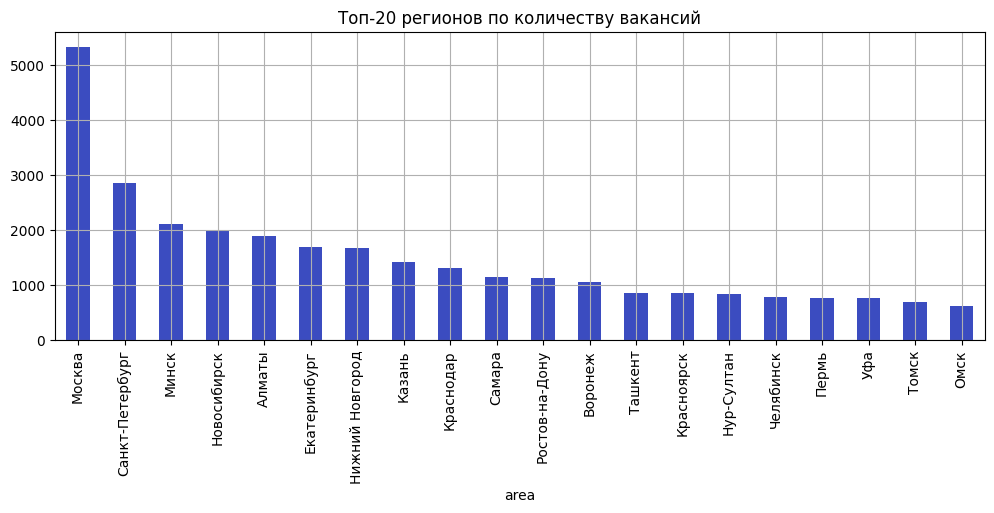

In [369]:
query_7_1 = f'''select a.name area,
                v.experience experience,
                round(avg(v.salary_from)/1000) avg_salary_min, 
                round(avg(salary_to)/1000) avg_salary_max, 
                count(v.id) vacancies_no
            from areas a
            join vacancies v on a.id = v.area_id
            group by a.name, v.experience
            order by vacancies_no desc
         '''
             
df_7_1 = pd.read_sql_query(query_test, connection)

grouped_area_1 = df_7_1.groupby(['area'])['vacancies_no'].last()
grouped_area_1 = grouped_area_1.nlargest(20)
grouped_area_1.plot(
    kind='bar',
    grid=True,
    figsize=(12, 4),
    colormap='coolwarm',
    
);

plt.title('Топ-20 регионов по количеству вакансий')

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\2835052357.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_7_2 = pd.read_sql_query(query_test, connection)


Text(0.5, 1.0, 'Топ-20 регионов по минимальной зарплате, тыс. руб.')

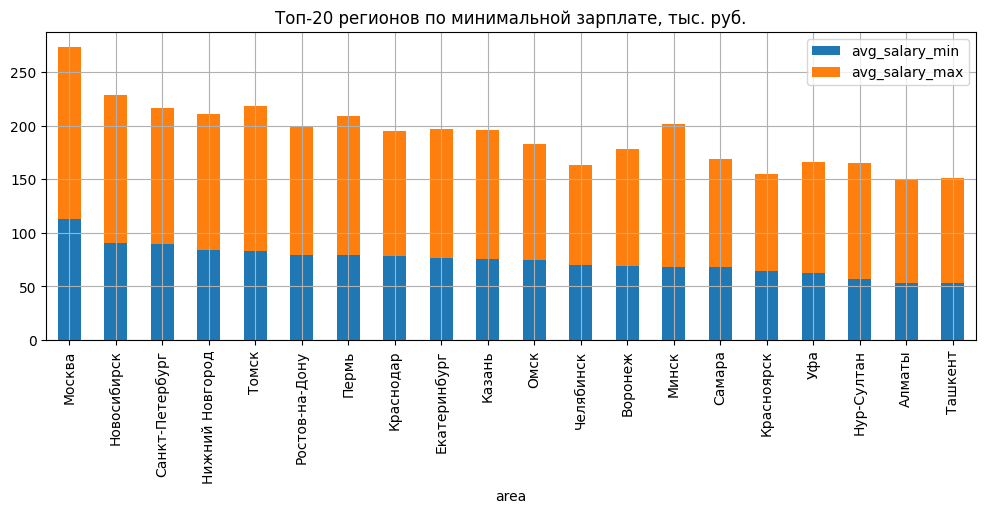

In [338]:
query_7_2 = f'''select a.name area,
                round(avg(v.salary_from)/1000) avg_salary_min, 
                round(avg(salary_to)/1000) - round(avg(v.salary_from)/1000) avg_salary_max, 
                count(v.id) vacancies_no
            from areas a
            join vacancies v on a.id = v.area_id
            group by a.name, v.experience
            order by vacancies_no desc
         '''
               
df_7_2 = pd.read_sql_query(query_test, connection)

grouped_area_2 = df_7_2.groupby(['area'])[['avg_salary_min', 'avg_salary_max']].last()
grouped_area_2 = grouped_area_2.nlargest(20, columns=['avg_salary_min'])
grouped_area.plot(
    kind='bar', 
    grid=True,
    stacked=True,
    figsize=(12, 4),
    legend=True
)
plt.title('Топ-20 регионов по минимальной зарплате, тыс. руб.')

C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\3843812514.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_7_3 = pd.read_sql_query(query_7_3, connection)


Text(0.5, 1.0, 'Топ-5 индустрий по количеству работодателей')

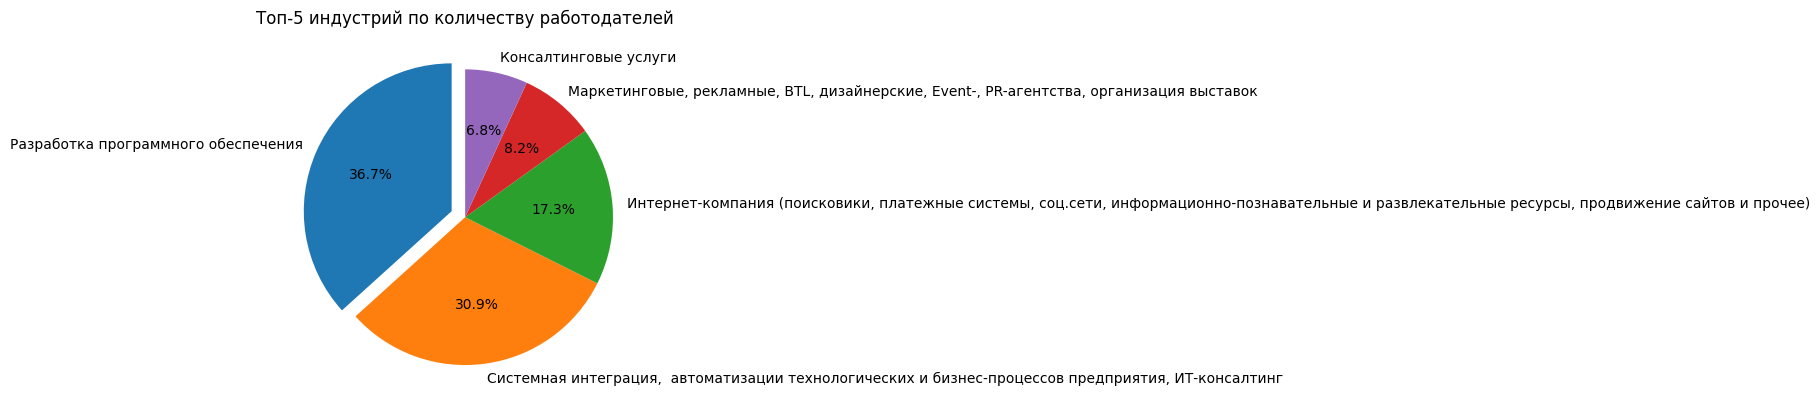

In [336]:
query_7_3 = f'''select i.name industry, 
                count(ie.employer_id) count
                from employers_industries ie
                join industries i on ie.industry_id = i.id
                group by i.name
                order by count(ie.employer_id) desc
                limit 5
            '''
                
df_7_3 = pd.read_sql_query(query_7_3, connection)
    
plt.pie(df_7_3['count'], labels=df_7_3['industry'], autopct='%1.1f%%', explode = [0.1, 0, 0, 0, 0], startangle=90)
plt.title('Топ-5 индустрий по количеству работодателей')



C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\393178781.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_7_4 = pd.read_sql_query(query_7_4, connection)
C:\Users\Ruzan\AppData\Local\Temp\ipykernel_17556\393178781.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_7_5 = pd.read_sql_query(query_7_5, connection)


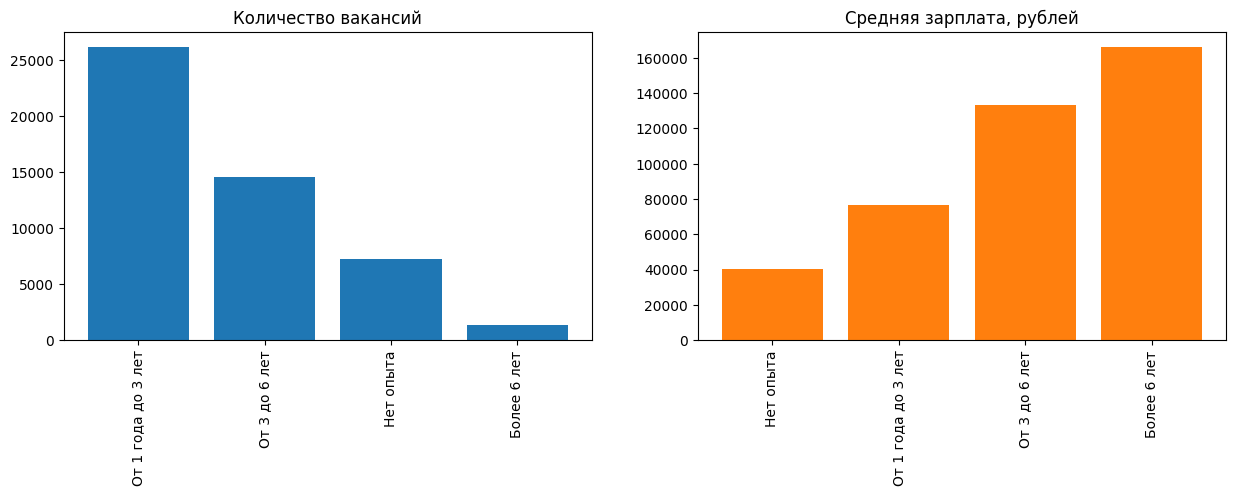

In [361]:
query_7_4 = f'''select v.experience experience,
                count(v.id) vacancies_no
            from vacancies v
            group by v.experience
            order by vacancies_no desc
         '''
query_7_5 = f'''select v.experience experience,
                round(avg((coalesce(salary_from,salary_to)+coalesce(salary_to,salary_from))/2)) avg_salary
            from vacancies v
            group by v.experience
            order by avg_salary asc
            '''
             
df_7_4 = pd.read_sql_query(query_7_4, connection)
df_7_5 = pd.read_sql_query(query_7_5, connection)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

# столбчатая диаграмма
axes[0].bar(
    x=df_7_4["experience"],
    height=df_7_4["vacancies_no"],
    label="Вакансии",
    color="#1F77B4"
)
axes[0].set_title("Количество вакансий")
axes[0].xaxis.set_tick_params(rotation=90)

axes[1].bar(
    x=df_7_5["experience"],
    height=df_7_5["avg_salary"],
    label="Сред. з\п, руб",
    color="#FF7F0E"
)
axes[1].set_title("Средняя зарплата, рублей")
axes[1].xaxis.set_tick_params(rotation=90)

